<a href="https://colab.research.google.com/github/juanjosedelgado-coder/Talleres/blob/main/Taller_Clustering_Natalia_Marleny_Juan_Vargas_Cuaspud_Delgado.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<a href="https://colab.research.google.com/github/LinaMariaCastro/curso-ia-para-economia/blob/main/clases/4_Aprendizaje_no_supervisado/1_Taller_Clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



# **Inteligencia Artificial con Aplicaciones en Economía I**

- 👩‍🏫 **Profesora:** [Lina María Castro](https://www.linkedin.com/in/lina-maria-castro)  
- 📧 **Email:** [lmcastroco@gmail.com](mailto:lmcastroco@gmail.com)  
- 🎓 **Universidad:** Universidad Externado de Colombia - Facultad de Economía

# **Taller: Agrupando Países por su Desarrollo Económico**

**IMPORTANTE**: Guarda una copia de este notebook en tu Google Drive o computador.

**Taller en grupos de 3**

**Nombres estudiantes:**

- Natalia Vargas
- Marleny Cuaspud
- Juan Jose Delgado

**Forma de entrega:**

- Nombrar el archivo de la siguiente forma:“Taller_Clustering_nombres_y_apellidos.ipynb”.
- Suba el Jupyter Notebook a su cuenta en Github y envíe el link en el siguiente Forms: https://forms.cloud.microsoft/r/P5SZPPS1Ve.

**IMPORTANTE:** No se recibirán talleres en Google Colab, el notebook debe estar subido en Github.

**Plazo de entrega:**

14 de abril de 2026, máximo a las 11:59 p.m. Tenga en cuenta que luego de esa hora el formulario en forms se cierra. El Jupupyter Notebook también debe quedar subido en Github antes de esa hora.

**Instrucciones Generales:**

Completa el código en las celdas marcadas con `### TU CÓDIGO AQUÍ ###`. Puedes añadir más celdas si lo requieres.

**Caso de Estudio: Consultoría para el PNUD**

**Contexto:** El Programa de las Naciones Unidas para el Desarrollo (PNUD) busca optimizar la asignación de recursos y la creación de políticas públicas. En lugar de aplicar
una única estrategia para todos, quieren entender si existen grupos de países con perfiles de desarrollo similares para crear programas de ayuda más efectivos.

**Tu Misión:** Como economista y científico de datos, tu equipo ha sido contratado para analizar un conjunto de datos con indicadores socio-económicos y de salud. Deberás aplicar técnicas de clustering para identificar estos grupos y presentar un perfil detallado de cada uno, junto con una recomendación de política.

## Ejercicio 1: Configuración inicial

1. Importa todas las librerías necesarias

In [1]:
### TU CÓDIGO AQUÍ ###
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
# Configuraciones de visualización
pd.options.display.max_columns = None
pd.options.display.float_format = '{:,.2f}'.format
sns.set(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)

## Ejercicio 2: Carga y Exploración de Datos

1. Carga el dataset 'Country-data.csv'.

In [3]:
### TU CÓDIGO AQUÍ ###
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
path = '/content/drive/MyDrive/IA Economia/Taller Clustering'

In [5]:
os.chdir(path)
os.listdir(path)

['Country-data.csv']

In [6]:
df = pd.read_csv('Country-data.csv')
df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.20,10.00,7.58,44.90,1610,9.44,56.20,5.82,553
1,Albania,16.60,28.00,6.55,48.60,9930,4.49,76.30,1.65,4090
2,Algeria,27.30,38.40,4.17,31.40,12900,16.10,76.50,2.89,4460
3,Angola,119.00,62.30,2.85,42.90,5900,22.40,60.10,6.16,3530
4,Antigua and Barbuda,10.30,45.50,6.03,58.90,19100,1.44,76.80,2.13,12200


2. Muestra las 5 primeras filas

In [7]:
print("Primeras filas:")
### TU CÓDIGO AQUÍ ###
df.head()

Primeras filas:


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.20,10.00,7.58,44.90,1610,9.44,56.20,5.82,553
1,Albania,16.60,28.00,6.55,48.60,9930,4.49,76.30,1.65,4090
2,Algeria,27.30,38.40,4.17,31.40,12900,16.10,76.50,2.89,4460
3,Angola,119.00,62.30,2.85,42.90,5900,22.40,60.10,6.16,3530
4,Antigua and Barbuda,10.30,45.50,6.03,58.90,19100,1.44,76.80,2.13,12200


3. Obtén información general del dataset como tipos de datos, número de filas y columnas, cantidad de valores faltantes

In [8]:
print("\nInformación del DataFrame:")
### TU CÓDIGO AQUÍ ###
df.info()

print("\nCantidad de valores faltantes:")

df.isnull().sum()


Información del DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB

Cantidad de valores faltantes:


,0
country,0
child_mort,0
exports,0
health,0
imports,0
income,0
inflation,0
life_expec,0
total_fer,0
gdpp,0


4. Obtén las estadísticas descriptivas de las variables del dataset

In [9]:
print("\nEstadísticas Descriptivas:")
### TU CÓDIGO AQUÍ ###
df.describe()


Estadísticas Descriptivas:


,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.00,167.00,167.00,167.00,167.00,167.00,167.00,167.00,167.00
mean,38.27,41.11,6.82,46.89,"17,144.69",7.78,70.56,2.95,"12,964.16"
std,40.33,27.41,2.75,24.21,"19,278.07",10.57,8.89,1.51,"18,328.70"
min,2.60,0.11,1.81,0.07,609.00,-4.21,32.10,1.15,231.00
25%,8.25,23.80,4.92,30.20,"3,355.00",1.81,65.30,1.79,"1,330.00"
50%,19.30,35.00,6.32,43.30,"9,960.00",5.39,73.10,2.41,"4,660.00"
75%,62.10,51.35,8.60,58.75,"22,800.00",10.75,76.80,3.88,"14,050.00"
max,208.00,200.00,17.90,174.00,"125,000.00",104.00,82.80,7.49,"105,000.00"


5. ¿Hay valores nulos?

**R/** No se observan valores nulos en el dataset, todas la variables tienen el mismo numero de observaciones



6. ¿Las escalas de las variables son muy diferentes?

**R/** si, las escalas son muy diferentes, por ejemplo en la variable ingreso anual (Annual Income) puede tener valores en rangos altos (decenas de miles), mientras que el Spending Score está en una escala de 1 a 100.

7. ¿Qué implicaciones tiene esto para el análisis de clustering?

**R/** Esta diferencia puede afectar los resultados del Clustering, especialmente en un algoritmo como K-Means, el cual se basa en distancias (como la euclidiana)

8. Redacta un análisis de las estadísticas descriptivas

**R/** Las estadísticas descriptivas muestran la distribución de las variables numéricas del dataset. Se observa que:

* La edad de los clientes presenta una dispersión moderada, lo que indica diversidad en el perfil demográfico.
* El ingreso anual tiene una variabilidad considerable, lo que sugiere diferencias económicas importantes entre los individuos.
* El Spending Score muestra una distribución relativamente amplia, lo que permite segmentar a los clientes según su comportamiento de consumo.

En conjunto, estas variables permiten identificar patrones y segmentar a los clientes en grupos homogeneos

## Ejercicio 3: Preprocesamiento de Datos

1. Selecciona solo las variables numéricas para el clustering

In [11]:
### TU CÓDIGO AQUÍ ###
x = df.drop(columns=['country'])
x.head()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,90.20,10.00,7.58,44.90,1610,9.44,56.20,5.82,553
1,16.60,28.00,6.55,48.60,9930,4.49,76.30,1.65,4090
2,27.30,38.40,4.17,31.40,12900,16.10,76.50,2.89,4460
3,119.00,62.30,2.85,42.90,5900,22.40,60.10,6.16,3530
4,10.30,45.50,6.03,58.90,19100,1.44,76.80,2.13,12200


2. Estandariza las variables usando StandardScaler

In [12]:
### TU CÓDIGO AQUÍ ###
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

## Ejercicio 4: K-Means Clustering

Usa K-Means para encontrar los clusters. Primero, debes decidir el número óptimo de clusters (k).

1. Usa el Método del Codo para encontrar el k óptimo.
Prueba un rango de k de 1 a 10. Grafica.

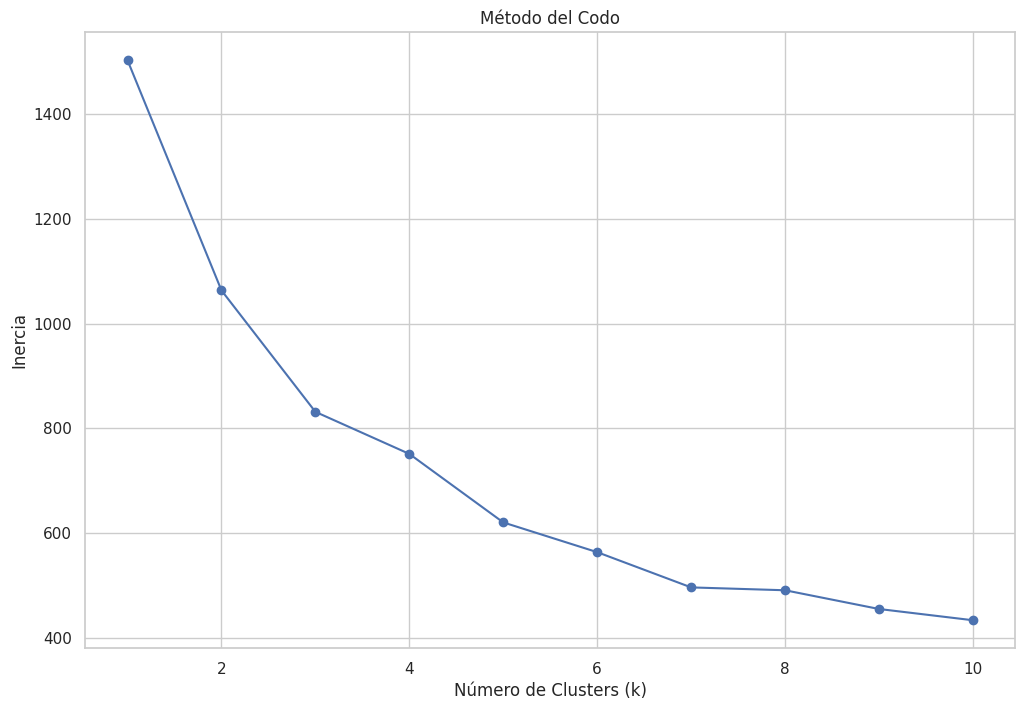

In [13]:
### TU CÓDIGO AQUÍ ###
from sklearn.cluster import KMeans

inercias = []
k_values = range(1, 11)

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(x_scaled)
    inercias.append(kmeans.inertia_)

plt.plot(k_values, inercias, marker='o')
plt.xlabel('Número de Clusters (k)')
plt.ylabel('Inercia')
plt.title('Método del Codo')
plt.show()

2. ¿Dónde está el "codo"? ¿Qué número de clusters (k) parece ser el más adecuado? Justifiquen su elección.

**R/** El “codo” se identifica en el punto donde la reducción de la inercia se vuelve menos pronunciada. En este caso, parece ubicarse alrededor de k = 3, lo que sugiere que ese número de clusters es adecuado.

3. Calcula y grafica el coeficiente de silueta

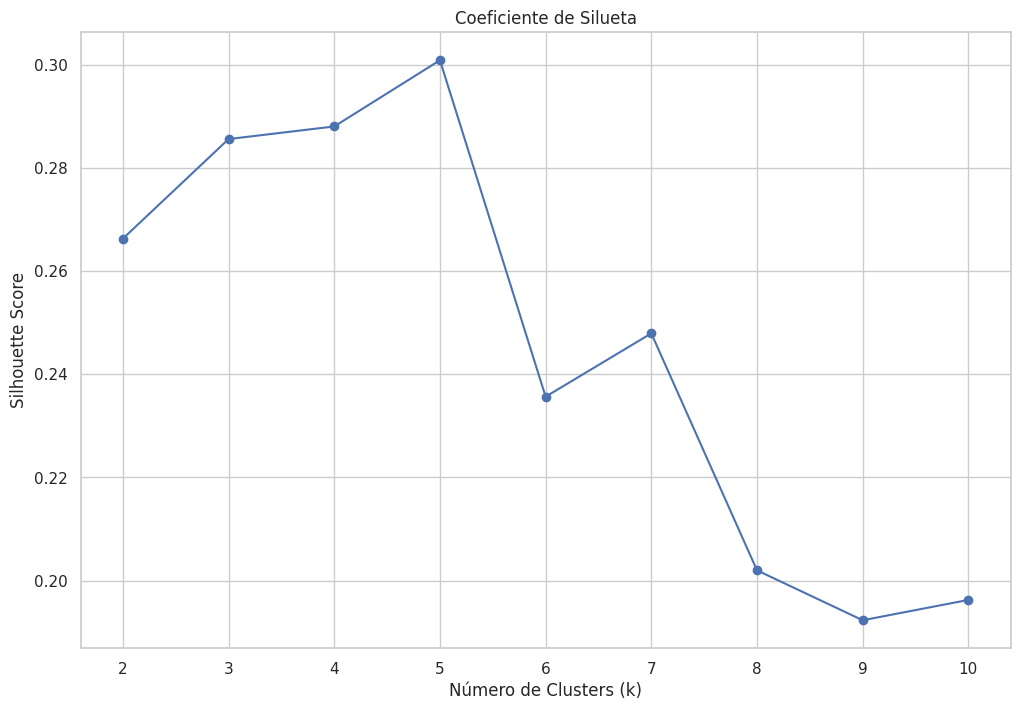

In [14]:
from sklearn.metrics import silhouette_score

silhouette_scores = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(x_scaled)
    score = silhouette_score(x_scaled, labels)
    silhouette_scores.append(score)

plt.plot(range(2, 11), silhouette_scores, marker='o')
plt.xlabel('Número de Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Coeficiente de Silueta')
plt.show()

4. ¿Qué número de clusters (k) parece ser el más adecuado según el coeficiente de silueta? Justifiquen su elección.

**R/** El coeficiente de silueta alcanza su valor máximo en k = 5 (aproximadamente 0.3), lo que sugiere una mejor separación de los clusters en comparación con otros valores de k. Sin embargo, este valor no es particularmente alto, indicando que la estructura de los clusters no es muy fuerte. Considerando además el método del codo, que sugiere k = 3, se puede optar por este valor como una solución más parsimoniosa y fácil de interpretar.

5. Basados en los resultados del método del codo y el coeficiente de silueta, tomen una decisión de cuántos clusters usar. Justifiquen su elección.

**R/**Con base en los resultados obtenidos, se decide utilizar k = 3 como número óptimo de clusters.

El método del codo sugiere claramente este valor, ya que a partir de k = 3 la reducción de la inercia se vuelve menos significativa, indicando rendimientos decrecientes al aumentar el número de clusters.

Por otro lado, aunque el coeficiente de silueta alcanza su valor máximo en k = 5, este valor es relativamente bajo (alrededor de 0.3), lo que sugiere que la separación entre clusters no es particularmente fuerte.

En este contexto, se prioriza el criterio del método del codo y la parsimonia del modelo, eligiendo k = 3 como una solución más simple, interpretable y adecuada para el análisis.

6. Aplica K-Means con el k que tu grupo eligió.

In [15]:
### TU CÓDIGO AQUÍ ###
# aplicar K-Means con K=3
kmeans = KMeans(n_clusters=3, random_state=42)
# ajustar el modelo y obtener clusters
clusters = kmeans.fit_predict(x_scaled)

7. Añade la asignación de clusters al DataFrame original

In [16]:
### TU CÓDIGO AQUÍ ###
df['cluster'] = clusters
df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,cluster
0,Afghanistan,90.20,10.00,7.58,44.90,1610,9.44,56.20,5.82,553,2
1,Albania,16.60,28.00,6.55,48.60,9930,4.49,76.30,1.65,4090,0
2,Algeria,27.30,38.40,4.17,31.40,12900,16.10,76.50,2.89,4460,0
3,Angola,119.00,62.30,2.85,42.90,5900,22.40,60.10,6.16,3530,2
4,Antigua and Barbuda,10.30,45.50,6.03,58.90,19100,1.44,76.80,2.13,12200,0


## Ejercicio 5: Análisis e Interpretación de los Clusters

Ahora que tienes los grupos, necesitas entender qué los caracteriza.

1. Calcula el promedio de cada variable para cada cluster.
Esto te dará el "perfil" de cada grupo.

In [18]:
### TU CÓDIGO AQUÍ ###
clusters_profile = df.drop(columns=['country']).groupby('cluster').mean(numeric_only=True)
clusters_profile

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
cluster,,,,,,,,,
0,22.46,40.27,6.25,47.36,"12,321.74",7.72,72.57,2.34,"6,461.77"
1,5.00,58.74,8.81,51.49,"45,672.22",2.67,80.13,1.75,"42,494.44"
2,95.11,28.60,6.30,42.31,"3,539.84",11.99,59.06,5.07,"1,766.71"


In [ ]:
display(clusters_profile)

2. Visualiza los resultados. Un scatter plot de 'gdpp' vs 'child_mort' es un buen punto de partida.

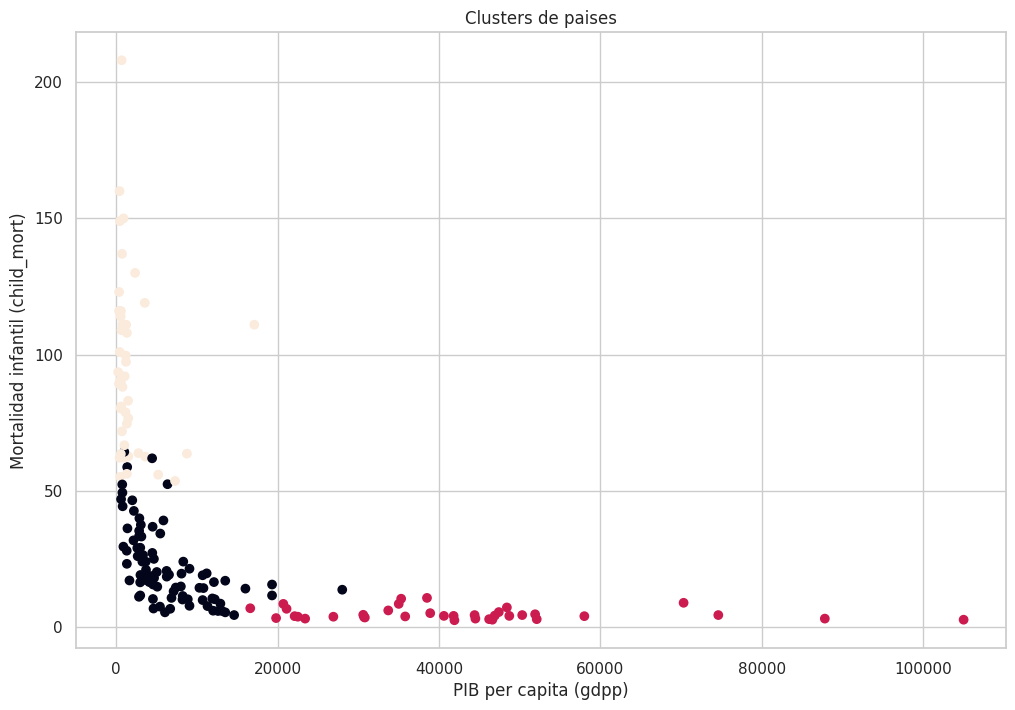

In [19]:
### TU CÓDIGO AQUÍ ###
plt.scatter(df['gdpp'], df['child_mort'], c=df['cluster'])
plt.xlabel('PIB per capita (gdpp)')
plt.ylabel('Mortalidad infantil (child_mort)')
plt.title('Clusters de paises')
plt.show()

3. **Nombra los clusters:** Basado en el perfil de cada uno, dale un nombre descriptivo.

**R/**

Cluster 0 (negro): Países en desarrollo intermedio

Cluster 1 (beige): Países de bajo desarrollo

Cluster 2 (rojo): Países desarrollados


4. **Describe cada cluster:** Para cada grupo, describe sus características principales.

**R/**

**Cluster 1:** Países de bajo desarrollo (beige)
* PIB per cápita: Muy bajo
* Mortalidad infantil: Muy alta (puede superar 100)
**Características:**
* Bajo acceso a servicios de salud
* Problemas de nutrición
* Infraestructura limitada
* Alta vulnerabilidad social

**Cluster 0:** Países en desarrollo intermedio (negro)
* PIB per cápita: Bajo a medio
* Mortalidad infantil: Moderada
**Características:**
* Mejora progresiva en salud y educación
* Transición económica
* Reducción gradual de la mortalidad infantil
* Desigualdad interna en algunos casos

**Cluster 2:** Países desarrollados (rojo)
* PIB per cápita: Alto
* Mortalidad infantil: Muy baja (cercana a 0–10)

**Características:**
* Sistemas de salud avanzados
* Alto nivel educativo
* Buena calidad de vida
* Alta inversión en bienestar social

5. **Recomendación de Política:** Elije un cluster y propón un tipo de programa de ayuda o política pública que el PNUD podría implementar para ellos.

**R/**

**Elegimos:** Cluster 1 (países de bajo desarrollo)

**Problema principal:** Alta mortalidad infantil + bajo ingreso.

**Propuesta de política:** Programa integral de salud materno-infantil

**Componentes:**

* Acceso gratuito a atención prenatal y postnatal
* Campañas de vacunación masiva
* Programas de nutrición infantil
* Capacitación de personal médico local
* Mejora de acceso a agua potable y saneamiento

**Justificación:**

Reducir la mortalidad infantil es clave porque:
* Mejora el capital humano a largo plazo
* Reduce la pobreza estructural
* Genera efectos positivos en educación y productividad